In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import math

In [2]:
# data
data = pd.read_csv(r".\viscosity_measurement_data.csv")

In [3]:
def viscosity_mix_calculation(T, waterVol, glycerolVol):
    #Variables ----------------

    # T = 20 				#temperature (degrees Celcius)
    # waterVol = 3 		#volume of water required (ml)
    # glycerolVol = 0.75	#volume of Glycerol used (ml)


    #Densities ----------------

    glycerolDen = (1273.3-0.6121*T)/1000 			#Density of Glycerol (g/cm3)
    waterDen = (1-math.pow(((abs(T-4))/622),1.7)) 	#Density of water (g/cm3)


    #Fraction cacluator ----------------

    glycerolMass=glycerolDen*glycerolVol
    waterMass=waterDen*waterVol
    totalMass=glycerolMass+waterMass
    mass_fraction=glycerolMass/totalMass
    vol_fraction= glycerolVol/(glycerolVol+waterVol)

    # print ("Mass fraction of mixture =", round(mass_fraction,5))
    # print ("Volume fraction of mixture =", round(vol_fraction,5))


    #Density calculator ----------------

    ##Andreas Volk polynomial method
    contraction_av = 1-math.pow(3.520E-8*((mass_fraction*100)),3)+math.pow(1.027E-6*((mass_fraction*100)),2)+2.5E-4*(mass_fraction*100)-1.691E-4
    contraction = 1+contraction_av/100

    ## Distorted sine approximation method
    #contraction_pc = 1.1*math.pow(math.sin(np.radians(math.pow(mass_fraction,1.3)*180)),0.85)
    #contraction = 1 + contraction_pc/100

    density_mix=(glycerolDen*vol_fraction+waterDen*(1-vol_fraction))*contraction

    # print ("Density of mixture =",round(density_mix,5),"g/cm3")


    #Viscosity calcualtor ----------------

    glycerolVisc=0.001*12100*np.exp((-1233+T)*T/(9900+70*T))
    waterVisc=0.001*1.790*np.exp((-1230-T)*T/(36100+360*T))

    a=0.705-0.0017*T
    b=(4.9+0.036*T)*np.power(a,2.5)
    alpha=1-mass_fraction+(a*b*mass_fraction*(1-mass_fraction))/(a*mass_fraction+b*(1-mass_fraction))
    A=np.log(waterVisc/glycerolVisc)

    viscosity_mix=glycerolVisc*np.exp(A*alpha)

    # print ("Viscosity of mxiture =",round(viscosity_mix,5), "Ns/m2")
    return mass_fraction, vol_fraction, viscosity_mix



In [4]:
# prepare viscosity_mix data
water_vol = 45
glycerol_vol_range = np.linspace(0, 45, 100)
T = 25
viscosity_calculation = pd.DataFrame(columns=['glycerol_vol', 'mass_fraction', 'vol_fraction', 'viscosity_mix'])
for glycerol_vol in glycerol_vol_range:
    mass_fraction, vol_fraction, viscosity_mix_value = viscosity_mix_calculation(T, water_vol, glycerol_vol)
    new_pd = pd.DataFrame([[glycerol_vol, mass_fraction, vol_fraction, viscosity_mix_value]], columns=['glycerol_vol', 'mass_fraction', 'vol_fraction', 'viscosity_mix'])
    viscosity_calculation = pd.concat([viscosity_calculation, new_pd], ignore_index=True)

In [5]:
# calculate volume fraction in data
# 1st row: 0 glycerol, 45 water
# 2nd row: 0 glycerol, 45 water
# 3rd row: 8.5 glycerol, 45 water
# 4th row: 17 glycerol, 45 water

data['vol%'] = [0/(0+45)*100, 0/(0+45)*100, 8.5/(8.5+45)*100, 17/(17+45)*100]

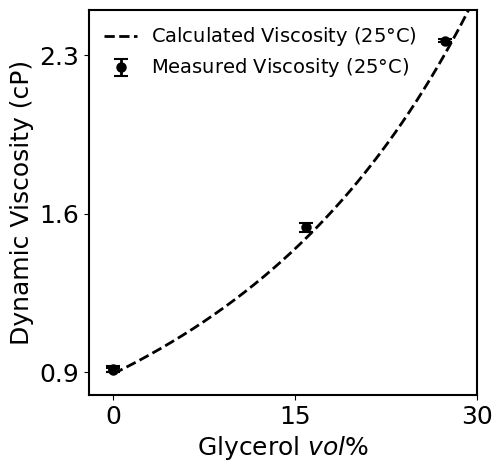

In [6]:
fig, ax = plt.subplots(figsize=(5, 5))

# Formatting parameters

# Error bars with hollow circles
ax.errorbar(
    data['vol%'], data['cP'],
    yerr=data['std cP'],
    fmt='o',
    capsize=5,              
    elinewidth=2,
    capthick=2,
    markersize=6,
    label='Measured Viscosity (25$\degree$C)',
    color='k',
    # markerfacecolor='w',
    markeredgewidth=1.5
)


# Glycerol-water mixture data
ax.plot(
    viscosity_calculation['vol_fraction'] * 100, 
    viscosity_calculation['viscosity_mix'] * 1000, 
    label='Calculated Viscosity (25$\degree$C)', color='k', linestyle='--', linewidth=2
)

# Labels and title
ax.set_xlabel('Glycerol $vol$%', fontsize=12)
ax.set_ylabel('Dynamic Viscosity (cP)', fontsize=12)
# ax.set_title('Glycerol-Water Mixture Viscosity', fontsize=14)
ax.legend(frameon=False, fontsize=12, loc='upper left')

# limits
ax.set_xlim([-2, 30])
ax.set_ylim([0.8, 2.5])

# labels
ax.tick_params(axis='both', which='major', labelsize=12)

# plt.figure(figsize=(6,5.5))

# ---Parameters---
ax = plt.gca()
# Font sizes
ax.tick_params(axis='both', which='major', labelsize=18)  # Tick label size

# Get the current content of the labels and title
xlabel = ax.get_xlabel()
ylabel = ax.get_ylabel()
title = ax.get_title()

# Set the font sizes without changing the content
ax.set_xlabel(xlabel, fontsize=18)  # X-axis label size
ax.set_ylabel(ylabel, fontsize=18)  # Y-axis label size
ax.set_title(title, fontsize=18)  # Title size

# Set legend size (if you have a legend)
legend = ax.get_legend()
if legend:
    for label in legend.get_texts():
        label.set_fontsize(14)

# Set text size for any additional annotations
for text in ax.texts:
    text.set_fontsize(16)

# Make axes thicker
for spine in ['top', 'right', 'bottom', 'left']:
    ax.spines[spine].set_linewidth(1.5)

# Reduce num of ticks
# ax.locator_params(axis='y', nbins=6)
# ax.locator_params(axis='x', nbins=6)
# set yticks
ax.set_yticks([0.9, 1.6, 2.3])
# set xticks
ax.set_xticks([0, 15, 30])

# # ---set box size---
# def set_size(w,h, ax=None):
#     """ w, h: width, height in inches """
#     if not ax: ax=plt.gca()
#     l = ax.figure.subplotpars.left
#     r = ax.figure.subplotpars.right
#     t = ax.figure.subplotpars.top
#     b = ax.figure.subplotpars.bottom
#     figw = float(w)/(r-l)
#     figh = float(h)/(t-b)
#     ax.figure.set_size_inches(figw, figh)

# set_size(5, 5)

## Save figure as PNG (optional), transparent background, not tight bounding box
# plt.savefig('viscosity_vs_glycerol.png', format='png', dpi=900, transparent=True, bbox_inches='tight')



In [7]:
	# 0.9 cP (45+0)
    # 1 cP (45+2)
	# 1.1 cP (45+3.5)
	# 1.2 cP (45+5)
	# 1.3 cP (45+6)
	# 1.4 cP (45+7.5)
	# 1.5 cP (45+8.5)
	# 1.6 cP (45+10)
	# 1.7 cP (45+11)
	# 1.8 cP (45+12)
	# 1.9 cP (45+13)
	# 2 cP (45+14)
	# 2.1 cP (45+15)
	# 2.2 cP (45+16)

# calculate volume fraction in data
df_full = pd.DataFrame(columns=['glycerol_vol', 'water_vol', 'mass_fraction', 'vol_fraction', 'viscosity_mix'])
for glycerol_vol in [0, 2, 3.5, 5, 6, 7.5, 8.5, 10, 11, 12, 13, 14, 15, 16]:
    water_vol = 45 
    mass_fraction, vol_fraction, viscosity_mix_value = viscosity_mix_calculation(T, water_vol, glycerol_vol)
    new_pd = pd.DataFrame([[glycerol_vol, water_vol, mass_fraction, vol_fraction, viscosity_mix_value]], columns=['glycerol_vol', 'water_vol', 'mass_fraction', 'vol_fraction', 'viscosity_mix'])
    df_full = pd.concat([df_full, new_pd], ignore_index=True)

# print vol_fraction and viscosity_mix values
print(df_full[['vol_fraction', 'viscosity_mix']])


    vol_fraction  viscosity_mix
0       0.000000       0.000893
1       0.042553       0.001015
2       0.072165       0.001114
3       0.100000       0.001219
4       0.117647       0.001293
5       0.142857       0.001409
6       0.158879       0.001490
7       0.181818       0.001617
8       0.196429       0.001706
9       0.210526       0.001799
10      0.224138       0.001894
11      0.237288       0.001992
12      0.250000       0.002094
13      0.262295       0.002200
